In [21]:
# Базовые библиотеки
import os
import math
import time
import random
from typing import Tuple, Dict, List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [22]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 12 if FAST_MODE else 25

Device: cuda


## Загрузка данных: STL10

In [23]:
# STL-10 mean/std (часто используемые значения)
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)

def load_stl10(data_dir: str = DATA_DIR):
    tf_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    # STL10 имеет разные наборы: train (5000 изображений) и test (8000 изображений)
    # Также есть дополнительный неразмеченный набор, но здесь используем размеченные
    ds_train_full = torchvision.datasets.STL10(root=data_dir, split='train', download=True, transform=tf_train)
    ds_test = torchvision.datasets.STL10(root=data_dir, split='test', download=True, transform=tf_test)

    return ds_train_full, ds_test

ds_train_full, ds_test = load_stl10()
class_names = ds_train_full.classes
print("Train full:", len(ds_train_full))
print("Test:", len(ds_test))
print("Classes:", class_names)

Train full: 5000
Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [24]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        # аккуратно: Subset от Subset (random_split возвращает Subset)
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=False)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=False)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=False)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test)

batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


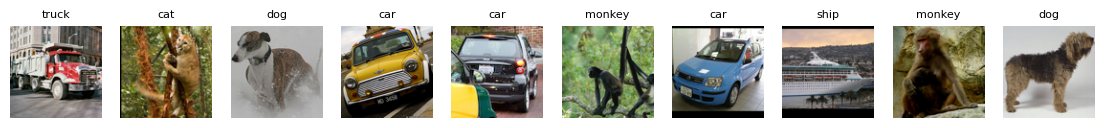

In [25]:
def denorm_stl10(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 4))  # Увеличил высоту для STL10 (96x96)
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

# Получаем имена классов
class_names = ds_train_full.classes

# Показываем изображения
show_images(train_loader, n=10)

In [26]:
INPUT_DIM = 96 * 96 * 3
NUM_CLASSES = 10
class SimpleCNN_STL10(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Вход: 3x96x96
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 96x96 -> 96x96
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 96x96 -> 48x48

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 48x48 -> 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 48x48 -> 24x24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 24x24 -> 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 24x24 -> 12x12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 12x12 -> 12x12
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 12x12 -> 6x6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),  # 256 * 36 = 9216
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x



In [27]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
cnn = SimpleCNN_STL10(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN_STL10(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)


In [28]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(DEVICE)  # STL10: 96x96
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])


In [29]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen
def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 50, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history
def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

## Эксперимент C1: CNN без аугментации

In [30]:
# cnn = SimpleCNN_STL10(NUM_CLASSES).to(DEVICE)
# выше создали модель

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
history = fit(cnn, train_loader, val_loader, optimizer, criterion, epochs=EPOCHS, verbose=True)


Epoch 01/25 | train loss 2.0500, acc 0.225 | val loss 1.7388, acc 0.328 | 3.0s
Epoch 02/25 | train loss 1.6457, acc 0.386 | val loss 1.4968, acc 0.424 | 3.0s
Epoch 03/25 | train loss 1.4718, acc 0.450 | val loss 1.3962, acc 0.469 | 3.0s
Epoch 04/25 | train loss 1.3271, acc 0.516 | val loss 1.3496, acc 0.485 | 4.1s
Epoch 05/25 | train loss 1.1898, acc 0.554 | val loss 1.2334, acc 0.536 | 3.0s
Epoch 06/25 | train loss 1.0787, acc 0.614 | val loss 1.2182, acc 0.556 | 3.0s
Epoch 07/25 | train loss 0.9841, acc 0.643 | val loss 1.2645, acc 0.534 | 3.0s
Epoch 08/25 | train loss 0.9053, acc 0.664 | val loss 1.1973, acc 0.577 | 4.1s
Epoch 09/25 | train loss 0.7570, acc 0.723 | val loss 1.1837, acc 0.584 | 3.0s
Epoch 10/25 | train loss 0.6684, acc 0.762 | val loss 1.2380, acc 0.605 | 3.0s
Epoch 11/25 | train loss 0.5774, acc 0.790 | val loss 1.1868, acc 0.612 | 3.0s
Epoch 12/25 | train loss 0.4593, acc 0.832 | val loss 1.3312, acc 0.601 | 4.1s
Epoch 13/25 | train loss 0.3691, acc 0.864 | val los

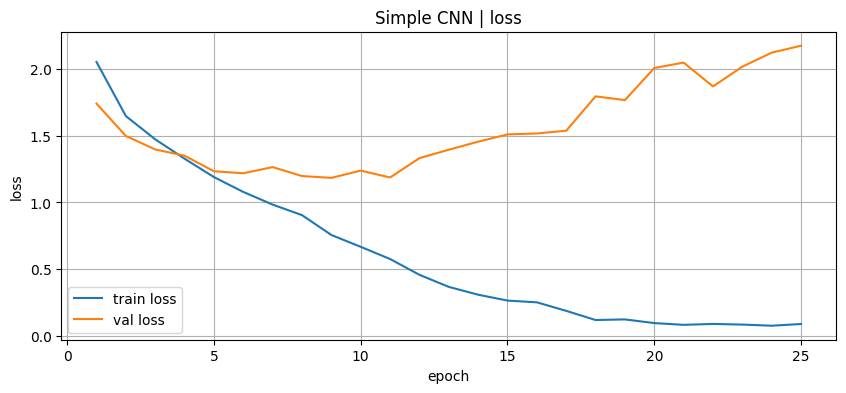

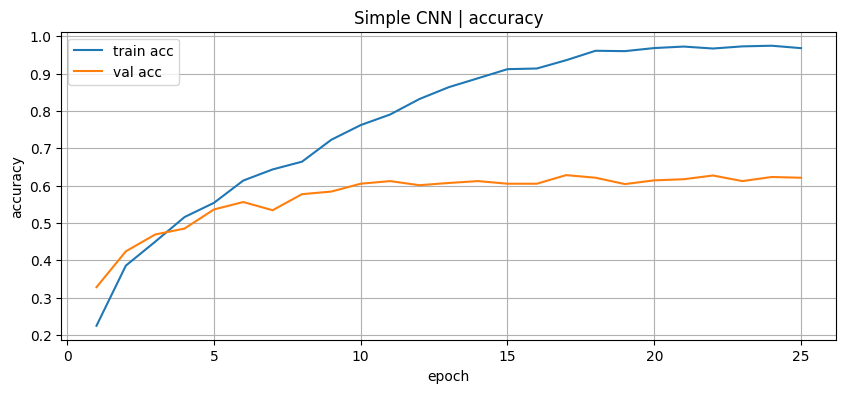

In [31]:
plot_history(history, title="Simple CNN")

In [32]:
# Лучшая валидационная точность
best_val_acc_c1 = float(np.nanmax(history["val_acc"]))
results_c1 = [{
    'experiment_id': 'C1',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': RANDOM_STATE,
    'model_summary': f'SimpleCNN_{count_params(cnn)}params',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc_c1,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'No augmentations'
}]

df = pd.DataFrame(results_c1)
df.to_csv('artifacts/runs.csv', index=False)

C2

In [33]:


# Создаем трансформации с аугментациями для тренировки
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

# Тестовые трансформации без аугментаций
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

# Загружаем датасет заново с новыми трансформациями
ds_train_full_aug = torchvision.datasets.STL10(
    root=DATA_DIR, split='train', download=True, transform=train_transform_aug
)
ds_test_aug = torchvision.datasets.STL10(
    root=DATA_DIR, split='test', download=True, transform=test_transform
)

# Создаем загрузчики
train_loader_aug, val_loader_aug, test_loader_aug = make_loaders(
    ds_train_full_aug, ds_test_aug, fast_mode=FAST_MODE
)

# Создаем модель (такая же как в C1)
cnn_c2 = SimpleCNN_STL10(NUM_CLASSES).to(DEVICE)
print(f"Model parameters: {count_params(cnn_c2)}")

# Оптимизатор и функция потерь
criterion_c2 = nn.CrossEntropyLoss()
optimizer_c2 = torch.optim.Adam(cnn_c2.parameters(), lr=1e-3, weight_decay=1e-4)

# Обучение
history_c2 = fit(cnn_c2, train_loader_aug, val_loader_aug, optimizer_c2, criterion_c2,
                 epochs=EPOCHS, verbose=True)





Model parameters: 5112650
Epoch 01/25 | train loss 2.1378, acc 0.201 | val loss 1.9051, acc 0.297 | 9.4s
Epoch 02/25 | train loss 1.8202, acc 0.315 | val loss 1.8031, acc 0.331 | 9.3s
Epoch 03/25 | train loss 1.6808, acc 0.365 | val loss 1.6437, acc 0.382 | 8.3s
Epoch 04/25 | train loss 1.5983, acc 0.393 | val loss 1.4743, acc 0.439 | 9.2s
Epoch 05/25 | train loss 1.4641, acc 0.440 | val loss 1.3908, acc 0.491 | 9.4s
Epoch 06/25 | train loss 1.3876, acc 0.477 | val loss 1.4014, acc 0.458 | 8.6s
Epoch 07/25 | train loss 1.3317, acc 0.500 | val loss 1.3913, acc 0.497 | 9.7s
Epoch 08/25 | train loss 1.2587, acc 0.539 | val loss 1.2654, acc 0.538 | 9.7s
Epoch 09/25 | train loss 1.2156, acc 0.549 | val loss 1.2344, acc 0.535 | 9.3s
Epoch 10/25 | train loss 1.1360, acc 0.579 | val loss 1.2157, acc 0.546 | 8.2s
Epoch 11/25 | train loss 1.1181, acc 0.586 | val loss 1.2110, acc 0.566 | 9.3s
Epoch 12/25 | train loss 1.0962, acc 0.593 | val loss 1.2796, acc 0.529 | 9.2s
Epoch 13/25 | train loss 1

In [34]:
# Лучшая валидационная точность
best_val_acc_c2 = float(np.nanmax(history_c2["val_acc"]))

# Сохранение результатов
results_c2 = [{
    'experiment_id': 'C2',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': RANDOM_STATE,
    'model_summary': f'SimpleCNN_{count_params(cnn_c2)}params',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc_c2,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'With augmentations (HorizontalFlip, Rotation, ColorJitter)'
}]

# Добавляем в runs.csv
df_c2 = pd.DataFrame(results_c2)
df_existing = pd.read_csv('artifacts/runs.csv')
df_updated = pd.concat([df_existing, df_c2], ignore_index=True)
df_updated.to_csv('artifacts/runs.csv', index=False)

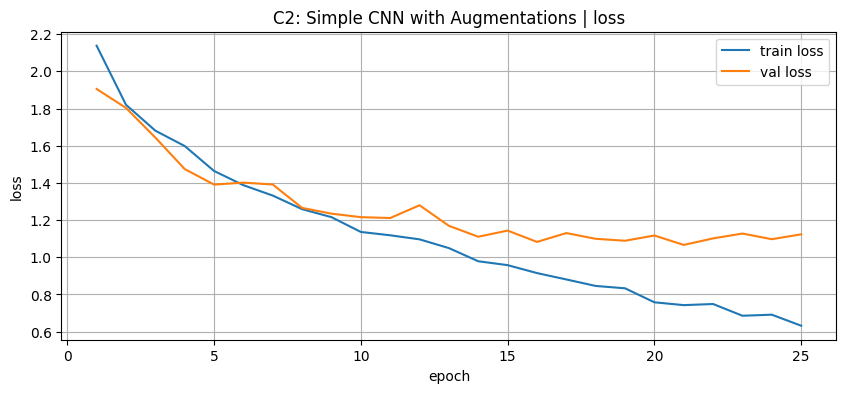

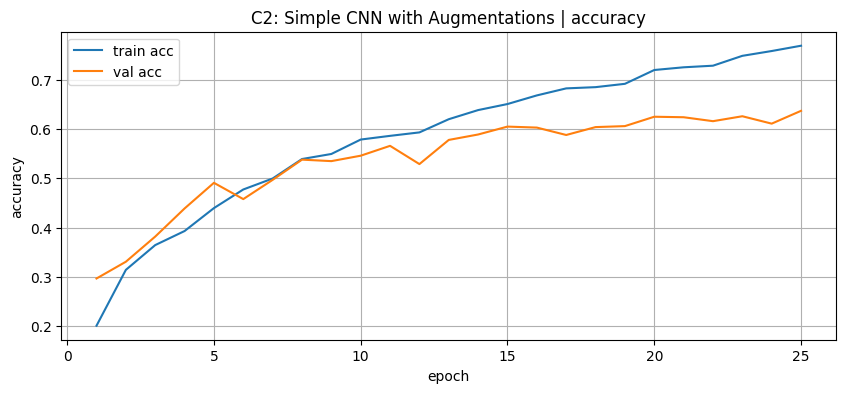

In [35]:
# График
plot_history(history_c2, title="C2: Simple CNN with Augmentations")

C3

In [36]:
from torchvision.models import resnet18, ResNet18_Weights

# Трансформации для ResNet (с нормализацией ImageNet)
RESNET_MEAN = [0.485, 0.456, 0.406]
RESNET_STD = [0.229, 0.224, 0.225]

train_transform_resnet = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),  # ResNet требует 224x224
    transforms.ToTensor(),
    transforms.Normalize(RESNET_MEAN, RESNET_STD),
])

test_transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(RESNET_MEAN, RESNET_STD),
])

# Загружаем датасет с новыми трансформациями
ds_train_full_resnet = torchvision.datasets.STL10(
    root=DATA_DIR, split='train', download=True, transform=train_transform_resnet
)
ds_test_resnet = torchvision.datasets.STL10(
    root=DATA_DIR, split='test', download=True, transform=test_transform_resnet
)

# Создаем загрузчики
train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders(
    ds_train_full_resnet, ds_test_resnet, fast_mode=FAST_MODE
)

# Загружаем предобученный ResNet18
resnet_c3 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Замораживаем все слои
for param in resnet_c3.parameters():
    param.requires_grad = False

# Заменяем классификатор на наш (10 классов)
num_features = resnet_c3.fc.in_features
resnet_c3.fc = nn.Linear(num_features, NUM_CLASSES)

resnet_c3 = resnet_c3.to(DEVICE)

print(f"Trainable parameters: {count_params(resnet_c3)}")
print(f"Total parameters: {sum(p.numel() for p in resnet_c3.parameters())}")

# Оптимизатор (обучается только новая голова)
criterion_c3 = nn.CrossEntropyLoss()
optimizer_c3 = torch.optim.Adam(resnet_c3.fc.parameters(), lr=1e-3, weight_decay=1e-4)

# Обучение
history_c3 = fit(resnet_c3, train_loader_resnet, val_loader_resnet, optimizer_c3,
                 criterion_c3, epochs=EPOCHS, verbose=True)


Trainable parameters: 5130
Total parameters: 11181642
Epoch 01/25 | train loss 1.6022, acc 0.522 | val loss 0.9506, acc 0.797 | 13.6s
Epoch 02/25 | train loss 0.7455, acc 0.841 | val loss 0.5716, acc 0.872 | 13.2s
Epoch 03/25 | train loss 0.5391, acc 0.866 | val loss 0.4837, acc 0.882 | 13.3s
Epoch 04/25 | train loss 0.4384, acc 0.888 | val loss 0.4296, acc 0.886 | 13.4s
Epoch 05/25 | train loss 0.3940, acc 0.896 | val loss 0.3890, acc 0.892 | 13.5s
Epoch 06/25 | train loss 0.3715, acc 0.892 | val loss 0.3946, acc 0.878 | 13.4s
Epoch 07/25 | train loss 0.3410, acc 0.902 | val loss 0.3613, acc 0.894 | 13.4s
Epoch 08/25 | train loss 0.3265, acc 0.904 | val loss 0.3489, acc 0.893 | 13.1s
Epoch 09/25 | train loss 0.3067, acc 0.909 | val loss 0.3127, acc 0.908 | 13.4s
Epoch 10/25 | train loss 0.2943, acc 0.908 | val loss 0.3348, acc 0.901 | 13.3s
Epoch 11/25 | train loss 0.2818, acc 0.915 | val loss 0.3232, acc 0.891 | 13.4s
Epoch 12/25 | train loss 0.2740, acc 0.918 | val loss 0.3064, acc 

In [37]:
# Лучшая валидационная точность
best_val_acc_c3 = float(np.nanmax(history_c3["val_acc"]))

# Сохранение результатов
results_c3 = [{
    'experiment_id': 'C3',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': RANDOM_STATE,
    'model_summary': f'ResNet18_head_only_{count_params(resnet_c3)}trainable_params',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc_c3,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'Pretrained ResNet18, frozen backbone, only fc layer trained'
}]

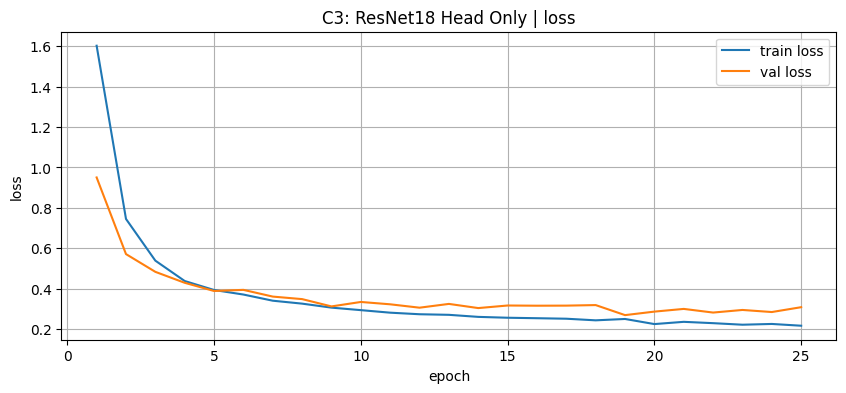

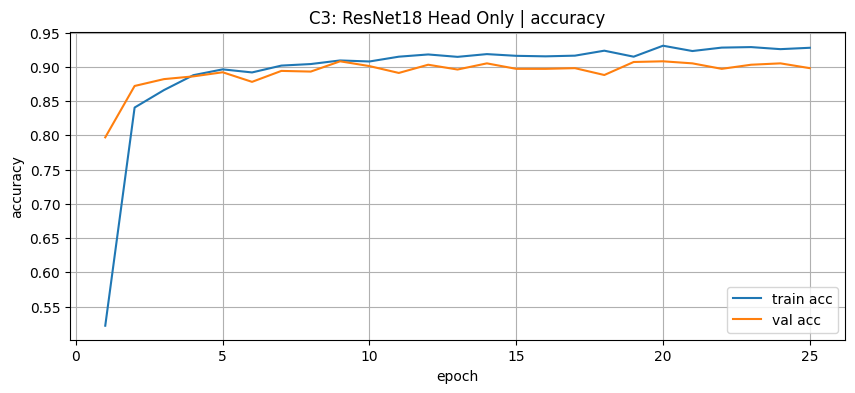

In [38]:
df_c3 = pd.DataFrame(results_c3)
df_existing = pd.read_csv('artifacts/runs.csv')
df_updated = pd.concat([df_existing, df_c3], ignore_index=True)
df_updated.to_csv('artifacts/runs.csv', index=False)

plot_history(history_c3, title="C3: ResNet18 Head Only")

C4

In [39]:
# Используем те же датасеты и загрузчики, что и в C3
# (они уже загружены с правильными трансформациями)

# Загружаем предобученный ResNet18
resnet_c4 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Замораживаем все слои
for param in resnet_c4.parameters():
    param.requires_grad = False

# Размораживаем последний блок (layer4)
for param in resnet_c4.layer4.parameters():
    param.requires_grad = True

# Заменяем классификатор на наш
num_features = resnet_c4.fc.in_features
resnet_c4.fc = nn.Linear(num_features, NUM_CLASSES)
# Классификатор уже требует градиенты по умолчанию

resnet_c4 = resnet_c4.to(DEVICE)

print(f"Trainable parameters: {count_params(resnet_c4)}")
print(f"Total parameters: {sum(p.numel() for p in resnet_c4.parameters())}")

# Оптимизатор с разными learning rates для разных частей
# Для layer4 и fc используем lr=1e-4, для остальных замороженных - не обновляем
optimizer_c4 = torch.optim.Adam([
    {'params': resnet_c4.layer4.parameters(), 'lr': 0.0001},
    {'params': resnet_c4.fc.parameters(), 'lr': 0.0001}
], weight_decay=1e-4)

criterion_c4 = nn.CrossEntropyLoss()

# Обучение
history_c4 = fit(resnet_c4, train_loader_resnet, val_loader_resnet, optimizer_c4,
                 criterion_c4, epochs=EPOCHS, verbose=True)

Trainable parameters: 8398858
Total parameters: 11181642
Epoch 01/25 | train loss 0.9872, acc 0.715 | val loss 0.4112, acc 0.876 | 14.0s
Epoch 02/25 | train loss 0.3097, acc 0.910 | val loss 0.3095, acc 0.908 | 14.0s
Epoch 03/25 | train loss 0.2050, acc 0.943 | val loss 0.2826, acc 0.907 | 14.3s
Epoch 04/25 | train loss 0.1441, acc 0.962 | val loss 0.2496, acc 0.924 | 14.4s
Epoch 05/25 | train loss 0.1172, acc 0.970 | val loss 0.2399, acc 0.924 | 14.5s
Epoch 06/25 | train loss 0.0888, acc 0.981 | val loss 0.2376, acc 0.927 | 14.5s
Epoch 07/25 | train loss 0.0687, acc 0.985 | val loss 0.2312, acc 0.923 | 14.0s
Epoch 08/25 | train loss 0.0634, acc 0.987 | val loss 0.2041, acc 0.926 | 13.9s
Epoch 09/25 | train loss 0.0474, acc 0.992 | val loss 0.2354, acc 0.928 | 14.2s
Epoch 10/25 | train loss 0.0362, acc 0.996 | val loss 0.2532, acc 0.921 | 14.0s
Epoch 11/25 | train loss 0.0355, acc 0.994 | val loss 0.2270, acc 0.928 | 14.2s
Epoch 12/25 | train loss 0.0323, acc 0.995 | val loss 0.2355, a

In [40]:
# Лучшая валидационная точность
best_val_acc_c4 = float(np.nanmax(history_c4["val_acc"]))

# Сохранение результатов
results_c4 = [{
    'experiment_id': 'C4',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': RANDOM_STATE,
    'model_summary': f'ResNet18_finetune_{count_params(resnet_c4)}trainable_params',
    'optimizer': 'Adam',
    'lr': '0.0001',
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc_c4,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'Pretrained ResNet18, layer4 + fc unfrozen, different LRs'
}]

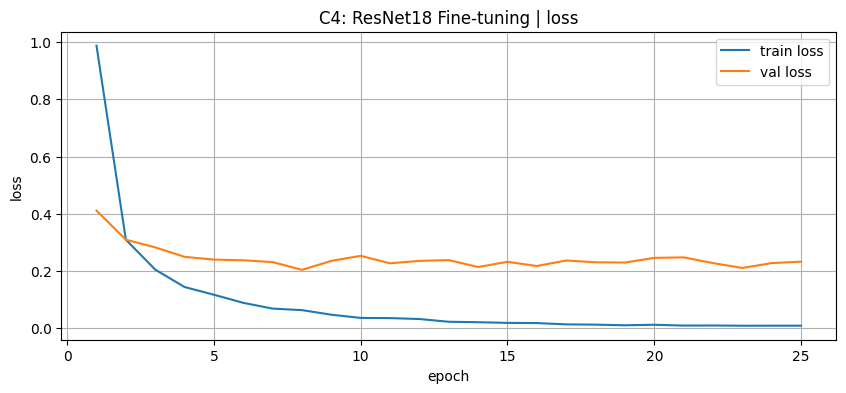

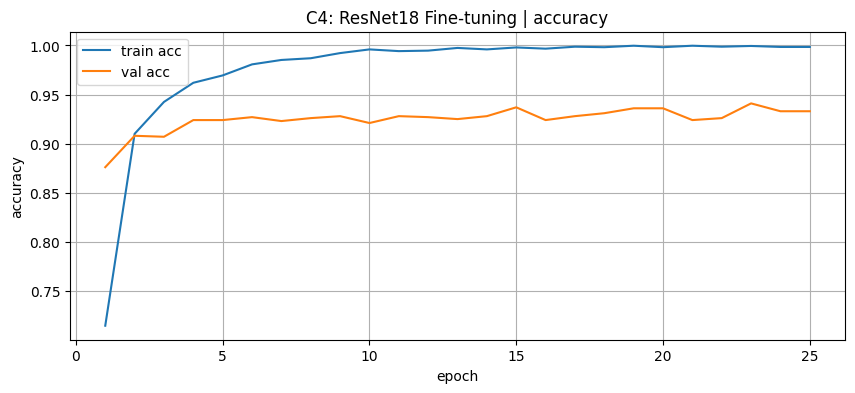

In [41]:
df_c4 = pd.DataFrame(results_c4)
df_existing = pd.read_csv('artifacts/runs.csv')
df_updated = pd.concat([df_existing, df_c4], ignore_index=True)
df_updated.to_csv('artifacts/runs.csv', index=False)

plot_history(history_c4, title="C4: ResNet18 Fine-tuning")

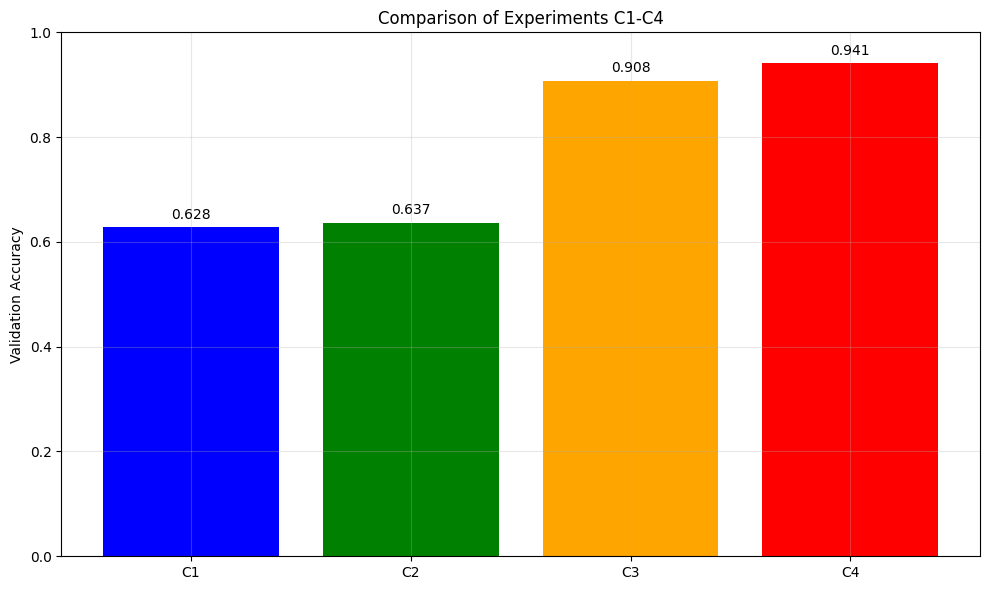


Best validation accuracies:
C1 (Simple CNN base): 0.6280
C2 (Simple CNN aug): 0.6370
C3 (ResNet head only): 0.9080
C4 (ResNet fine-tune): 0.9410

Best model: C4 with validation accuracy: 0.9410


In [42]:
# Собираем результаты
experiments = ['C1', 'C2', 'C3', 'C4']
val_accs = [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4]

# Создаем bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(experiments, val_accs, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Experiments C1-C4')
plt.ylim(0, 1)

# Добавляем значения на столбцы
for bar, val in zip(bars, val_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/classification_compare.png', dpi=100)
plt.show()

print("\nBest validation accuracies:")
print(f"C1 (Simple CNN base): {best_val_acc_c1:.4f}")
print(f"C2 (Simple CNN aug): {best_val_acc_c2:.4f}")
print(f"C3 (ResNet head only): {best_val_acc_c3:.4f}")
print(f"C4 (ResNet fine-tune): {best_val_acc_c4:.4f}")

# Определяем лучшую модель
best_exp = experiments[np.argmax(val_accs)]
best_acc = max(val_accs)
print(f"\nBest model: {best_exp} with validation accuracy: {best_acc:.4f}")

In [43]:
# Сохраняем лучшую модель (C4 обычно должна быть лучшей)
best_model = resnet_c4  # или другая, если у вас получилось иначе
best_val_acc = best_val_acc_c4

# Сохраняем state_dict
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

# Сохраняем конфиг
import json

config = {
    'dataset': 'STL10',
    'model': 'ResNet18_finetune',
    'pretrained': True,
    'transforms': {
        'train': 'RandomHorizontalFlip, RandomRotation(15), ColorJitter, Resize(224), Normalize(ImageNet)',
        'val': 'Resize(224), Normalize(ImageNet)'
    },
    'optimizer': 'Adam',
    'optimizer_params': {
        'lr': {'layer4': 1e-4, 'fc': 1e-3},
        'weight_decay': 1e-4
    },
    'epochs': EPOCHS,
    'best_val_accuracy': best_val_acc,
    'seed': RANDOM_STATE,
    'device': str(DEVICE)
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Best model and config saved!")

Best model and config saved!



Визуализация аугментаций


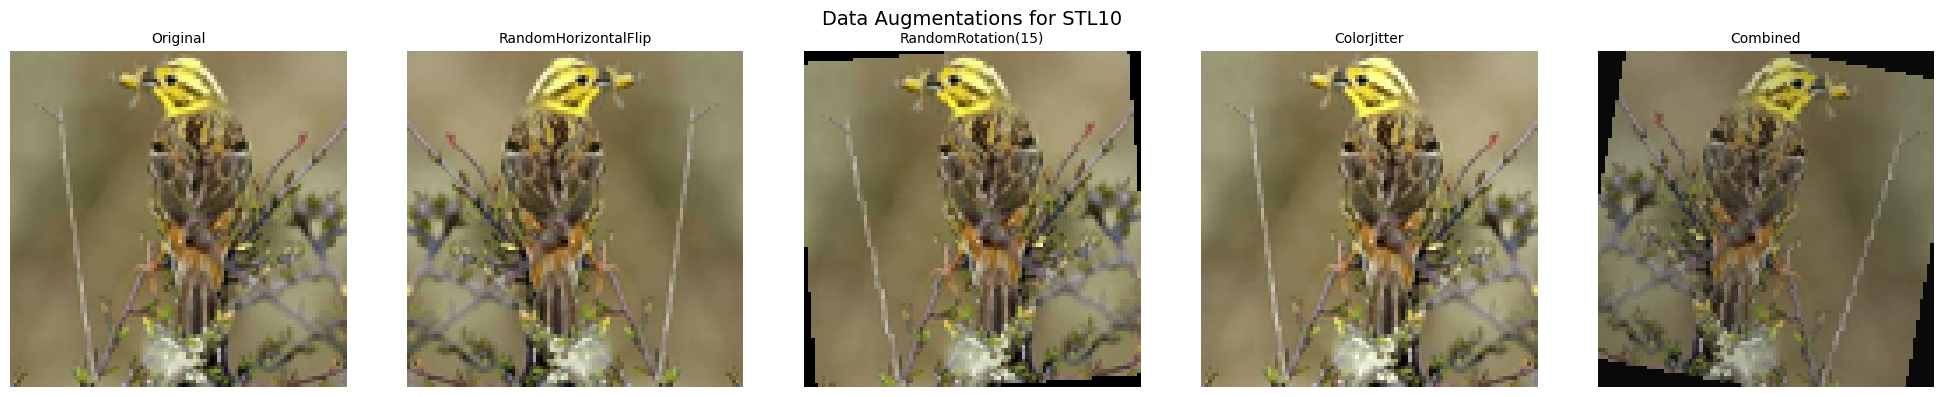

Сохранено: augmentations_preview.png


In [76]:
# Визуализация аугментаций для части A
print("\n" + "="*50)
print("Визуализация аугментаций")
print("="*50)

# Берем одно изображение из датасета ДО трансформаций
# Загружаем сырое изображение без трансформаций
raw_dataset = torchvision.datasets.STL10(
    root=DATA_DIR,
    split='train',
    download=True,
    transform=None  # Без трансформаций
)

sample_img_raw, _ = raw_dataset[0]  # Это будет PIL Image

# Создаем разные аугментации
augmentations = [
    ("Original", transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])),
    ("RandomHorizontalFlip", transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])),
    ("RandomRotation(15)", transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])),
    ("ColorJitter", transforms.Compose([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])),
    ("Combined", transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ]))
]

# Визуализация
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (name, transform) in enumerate(augmentations):
    # Применяем аугментацию к PIL Image
    img_tensor = transform(sample_img_raw)

    # Денормализуем для отображения
    img_disp = denorm_stl10(img_tensor).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[idx].imshow(img_disp)
    axes[idx].set_title(name, fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Data Augmentations for STL10', fontsize=14)
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png', dpi=100)
plt.show()
print("Сохранено: augmentations_preview.png")

ЧАСТЬ B: Сегментация с OxfordIIITPet

In [87]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import torchvision.models as models
import torchvision.transforms as T

In [88]:
set_seed(RANDOM_STATE)

In [89]:
# Load OxfordIIITPet
pet_ds = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split="test", target_types="segmentation", download=True,
)
print(f"OxfordIIITPet test: {len(pet_ds)} images")

OxfordIIITPet test: 3669 images


Image type: <class 'PIL.Image.Image'>, size: (300, 225)
Mask type: <class 'PIL.PngImagePlugin.PngImageFile'>, size: (300, 225), unique values: [1 2 3]
Mask shape (as array): (225, 300)


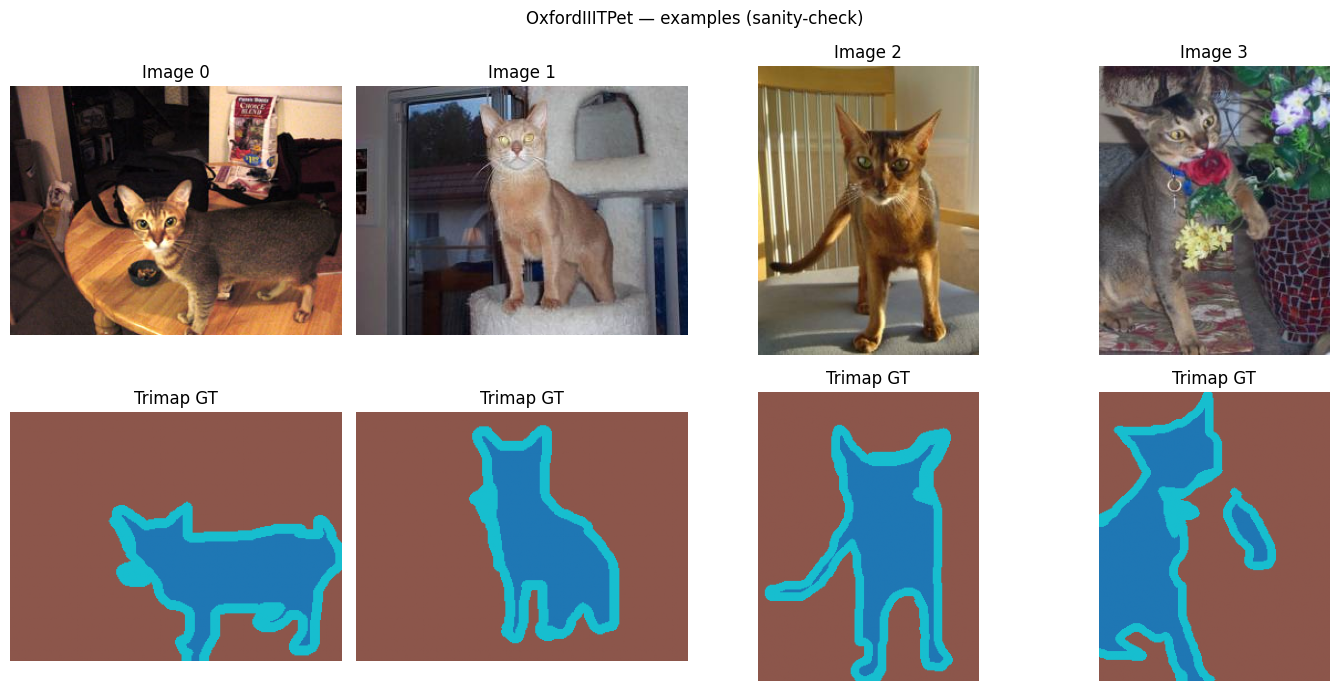

In [90]:
# Sanity-check Part B
img_sample, mask_sample = pet_ds[0]
print(f"Image type: {type(img_sample)}, size: {img_sample.size}")
mask_np = np.array(mask_sample)
print(f"Mask type: {type(mask_sample)}, size: {mask_sample.size}, "
      f"unique values: {np.unique(mask_np)}")
print(f"Mask shape (as array): {mask_np.shape}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    img, mask = pet_ds[i]
    axes[0][i].imshow(img)
    axes[0][i].set_title(f"Image {i}")
    axes[0][i].axis("off")
    axes[1][i].imshow(np.array(mask), cmap="tab10", vmin=1, vmax=3)
    axes[1][i].set_title("Trimap GT")
    axes[1][i].axis("off")
plt.suptitle("OxfordIIITPet — examples (sanity-check)")
plt.tight_layout()
plt.show()

In [91]:
# Pretrained segmentation model
seg_model = models.segmentation.deeplabv3_resnet50(
    weights=models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
).to(DEVICE).eval()

seg_preprocess = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

CAT_CLS, DOG_CLS = 8, 12

In [92]:
# Prediction & metric helpers
def predict_pet_mask(model, img_pil, preprocess, dev, mode="v1"):
    """
    V1 (mode='v1'): argmax по 21 классу → foreground = cat | dog.
    V2 (mode='v2'): softmax P(cat)+P(dog) > 0.5.
    """
    inp = preprocess(img_pil).unsqueeze(0).to(dev)
    with torch.no_grad():
        logits = model(inp)["out"]  # [1, 21, H, W]
    if mode == "v1":
        cls_map = logits.argmax(1).squeeze(0).cpu().numpy()
        return ((cls_map == CAT_CLS) | (cls_map == DOG_CLS)).astype(np.uint8)
    else:
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pet_prob = probs[CAT_CLS] + probs[DOG_CLS]
        return (pet_prob > 0.5).astype(np.uint8)


def seg_metrics(pred, gt):
    """IoU, pixel-precision, pixel-recall для бинарных масок."""
    p, g = pred.astype(bool), gt.astype(bool)
    inter = (p & g).sum()
    union = (p | g).sum()
    iou = inter / max(union, 1)
    prec = inter / max(p.sum(), 1)
    rec = inter / max(g.sum(), 1)
    return float(iou), float(prec), float(rec)


In [94]:
# Evaluate V1 and V2
N_EVAL = 100
m_v1 = {"iou": [], "prec": [], "rec": []}
m_v2 = {"iou": [], "prec": [], "rec": []}

for i in range(N_EVAL):
    img_pil, mask_pil = pet_ds[i]
    gt = np.array(mask_pil.resize((256, 256), Image.NEAREST))
    gt_fg = (gt == 1).astype(np.uint8)  # trimap: 1=foreground

    p1 = predict_pet_mask(seg_model, img_pil, seg_preprocess, DEVICE, "v1")
    p2 = predict_pet_mask(seg_model, img_pil, seg_preprocess, DEVICE, "v2")

    i1, pr1, rc1 = seg_metrics(p1, gt_fg)
    i2, pr2, rc2 = seg_metrics(p2, gt_fg)
    for d, vals in [(m_v1, (i1, pr1, rc1)), (m_v2, (i2, pr2, rc2))]:
        d["iou"].append(vals[0])
        d["prec"].append(vals[1])
        d["rec"].append(vals[2])

mean_v1 = {k: float(np.mean(v)) for k, v in m_v1.items()}
mean_v2 = {k: float(np.mean(v)) for k, v in m_v2.items()}

print("V1 (argmax)  :", {k: f"{v:.4f}" for k, v in mean_v1.items()})
print("V2 (prob>0.5):", {k: f"{v:.4f}" for k, v in mean_v2.items()})

V1 (argmax)  : {'iou': '0.7396', 'prec': '0.7543', 'rec': '0.9810'}
V2 (prob>0.5): {'iou': '0.7400', 'prec': '0.7597', 'rec': '0.9756'}


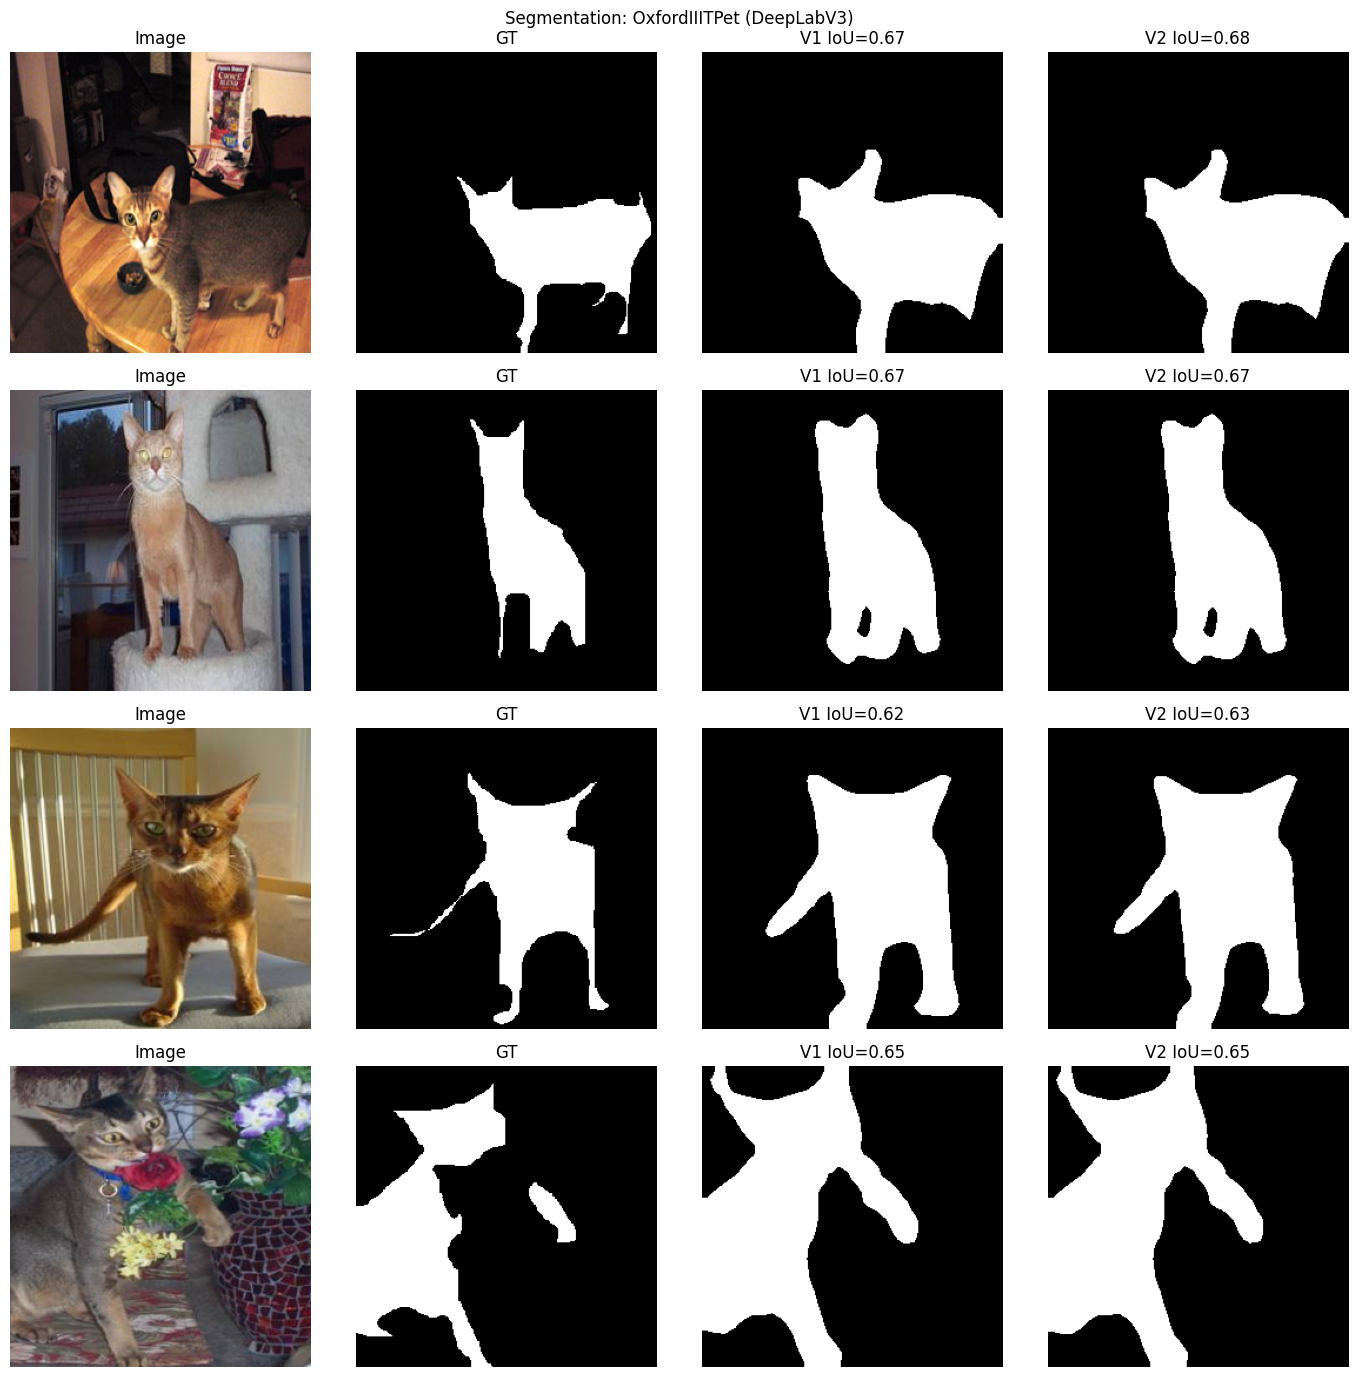

In [96]:
# Segmentation visualisation
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for row in range(4):
    img_pil, mask_pil = pet_ds[row]
    gt = np.array(mask_pil.resize((256, 256), Image.NEAREST))
    gt_fg = (gt == 1).astype(np.uint8)
    p1 = predict_pet_mask(seg_model, img_pil, seg_preprocess, DEVICE, "v1")
    p2 = predict_pet_mask(seg_model, img_pil, seg_preprocess, DEVICE, "v2")

    axes[row][0].imshow(img_pil.resize((256, 256)))
    axes[row][0].set_title("Image")
    i1, _, _ = seg_metrics(p1, gt_fg)
    axes[row][1].imshow(gt_fg, cmap="gray")
    axes[row][1].set_title("GT")
    axes[row][2].imshow(p1, cmap="gray")
    axes[row][2].set_title(f"V1 IoU={i1:.2f}")
    i2, _, _ = seg_metrics(p2, gt_fg)
    axes[row][3].imshow(p2, cmap="gray")
    axes[row][3].set_title(f"V2 IoU={i2:.2f}")
    for c in range(4):
        axes[row][c].axis("off")

plt.suptitle("Segmentation: OxfordIIITPet (DeepLabV3)")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png", dpi=100, bbox_inches="tight")
plt.show()

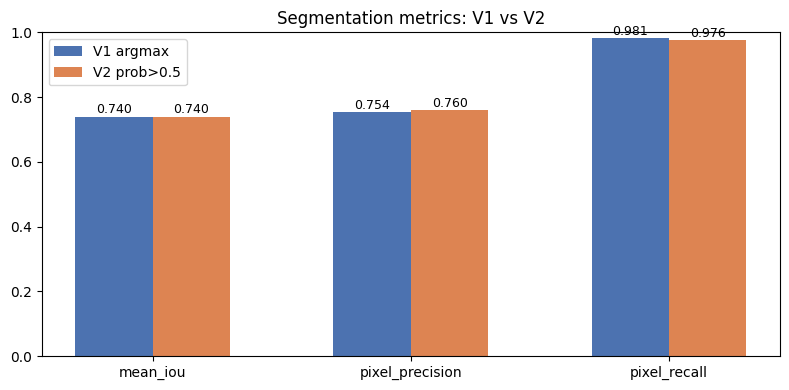

In [97]:
# Segmentation metrics bar chart
met_names = ["mean_iou", "pixel_precision", "pixel_recall"]
v1v = [mean_v1["iou"], mean_v1["prec"], mean_v1["rec"]]
v2v = [mean_v2["iou"], mean_v2["prec"], mean_v2["rec"]]

x = np.arange(len(met_names))
w = 0.3
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w / 2, v1v, w, label="V1 argmax", color="#4c72b0")
b2 = ax.bar(x + w / 2, v2v, w, label="V2 prob>0.5", color="#dd8452")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(met_names)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Segmentation metrics: V1 vs V2")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png", dpi=100, bbox_inches="tight")
plt.show()


Графики обучения лучшей модели


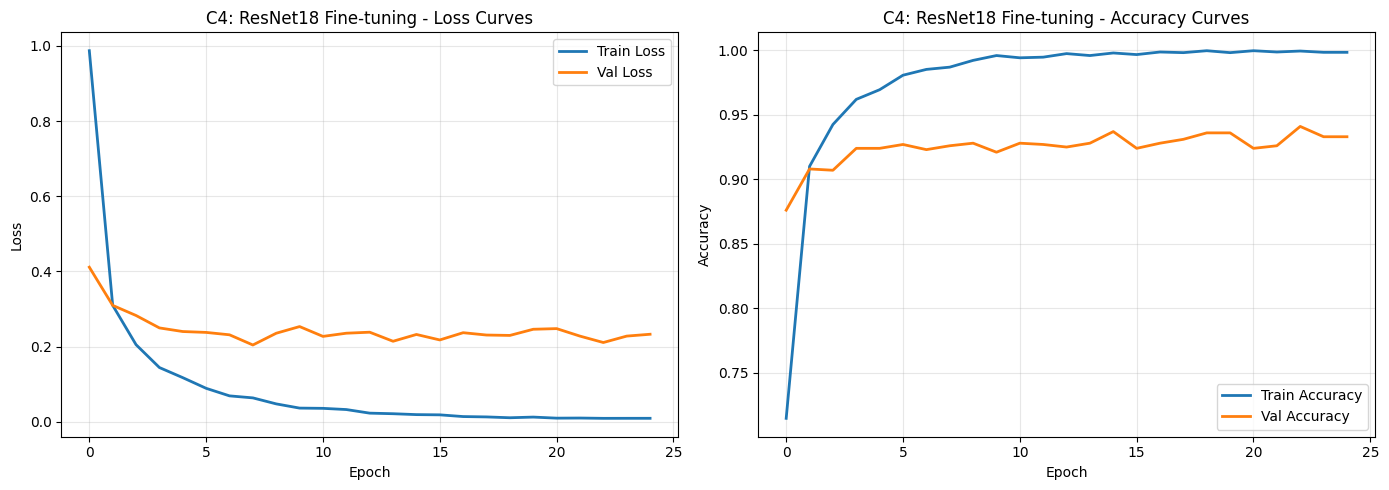

Сохранено: classification_curves_best.png


In [98]:
# Графики обучения лучшей модели (C4 обычно лучший)
print("\n" + "="*50)
print("Графики обучения лучшей модели")
print("="*50)

# Определяем лучшую модель и ее историю
best_history = history_c4  # или history_c3, если C3 оказался лучше
best_model_name = "C4: ResNet18 Fine-tuning"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(best_history["train_loss"], label='Train Loss', linewidth=2)
axes[0].plot(best_history["val_loss"], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'{best_model_name} - Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(best_history["train_acc"], label='Train Accuracy', linewidth=2)
axes[1].plot(best_history["val_acc"], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{best_model_name} - Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=100)
plt.show()
print("Сохранено: classification_curves_best.png")

In [99]:
# Финальная оценка на test set (только для лучшей модели)
print("\n" + "="*50)
print("Финальная оценка лучшей модели на test set")
print("="*50)

# Выбираем лучшую модель (C4 или C3)
best_model_for_test = resnet_c4  # или resnet_c3
best_model_name = "C4: ResNet18 Fine-tuning"

# Оцениваем на test
test_loss, test_acc = evaluate(best_model_for_test, test_loader_resnet, criterion_c4)
print(f"Лучшая модель ({best_model_name})")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Обновляем runs.csv с test_accuracy для лучшей модели
df = pd.read_csv('artifacts/runs.csv')
df.loc[df['experiment_id'] == 'C4', 'test_accuracy'] = test_acc
df.to_csv('artifacts/runs.csv', index=False)
print("Test accuracy добавлена в runs.csv")


Финальная оценка лучшей модели на test set
Лучшая модель (C4: ResNet18 Fine-tuning)
Test Loss: 0.1615
Test Accuracy: 0.9513
Test accuracy добавлена в runs.csv
